# Experiment 1: Temperature Spectrum
This notebook runs the stochastic attention sampler (Algorithm 1) across a range of inverse temperatures on a fixed memory matrix.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Characterize temperature regimes:__ Identify and distinguish the retrieval (large beta), generation (intermediate beta), and diffuse (small beta) regimes of the stochastic attention sampler
> * __Measure retrieval quality:__ Compute cosine similarity between sampled states and their nearest stored pattern as a function of inverse temperature
> * __Interpret the attention entropy order parameter:__ Use the Shannon entropy of attention weights H(p) to quantify the phase transition from disorder to order

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [73]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

___
## Load the Synthetic Data
Load the pre-generated dataset (dataset 1 of 5) from the data generation step.

In [74]:
# Load the JLD2 archive for experiment 1
exp1_data = JLD2.load(joinpath(_PATH_TO_DATA, "exp1_temperature", "data.jld2"), "result");
X = exp1_data["datasets"][1]  # 64 × 16 memory matrix
d, K = size(X)
println("Memory matrix X: $d dimensions × $K patterns")
println("Column norms: ", [round(norm(X[:, k]); digits=4) for k in 1:K])

Memory matrix X: 64 dimensions × 16 patterns
Column norms: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


___
## Define the Temperature Sweep
We sweep $\beta$ over several orders of magnitude, from very cold (retrieval) to very hot (diffuse).

> __Temperature regimes:__ At large $\beta$ (low temperature), the chain locks onto the nearest stored pattern (retrieval/MAP). At intermediate $\beta$, the chain generates novel states that are structured convex combinations of stored memories. At small $\beta$ (high temperature), sampling becomes noise-dominated and diffuse.

In [75]:
# Inverse temperature values (dense log-spaced for smooth curves)
β_values = [0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 7.5,
            10.0, 15.0, 25.0, 40.0, 50.0, 75.0, 100.0, 150.0, 250.0, 500.0, 750.0, 1000.0]

# Sampler configuration
α = 0.01        # step size (small to control discretization bias at high β)
T = 10000       # number of iterations (longer chain to compensate for smaller α)
T_burnin = 2000 # discard first T_burnin samples as burn-in

# Initial state: random unit-norm vector (same for all β for fair comparison)
Random.seed!(9999)
ξ₀ = randn(d)
ξ₀ ./= norm(ξ₀)

println("β values ($(length(β_values)) points): ", β_values)
println("Step size α = $α, iterations T = $T, burn-in = $T_burnin")

β values (25 points): [0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0, 25.0, 40.0, 50.0, 75.0, 100.0, 150.0, 250.0, 500.0, 750.0, 1000.0]
Step size α = 0.01, iterations T = 10000, burn-in = 2000


___
## Run the Sampler Across All $\beta$ Values
For each $\beta$, run Algorithm 1 and compute the cosine similarity of each post-burn-in sample to its nearest stored pattern.

In [76]:
# Storage for results
results = Dict{Float64, Vector{Float64}}()  # β => vector of cosine similarities

for β in β_values
    # Run the sampler
    (t, Ξ) = sample(X, ξ₀, T; β=β, α=α, seed=12345)
    
    # Compute cosine similarity for each post-burn-in sample
    sims = Float64[]
    for i in (T_burnin + 2):(T + 1)  # +2 because row 1 is t=0
        ξ_t = Ξ[i, :]
        push!(sims, nearest_cosine_similarity(ξ_t, X))
    end
    results[β] = sims
    
    println("β = $(lpad(β, 6)): mean cos-sim = $(round(mean(sims); digits=4)), ",
            "std = $(round(std(sims); digits=4))")
end

β =   0.01: mean cos-sim = 0.2192, std = 0.0696
β =  0.025: mean cos-sim = 0.2197, std = 0.0696
β =   0.05: mean cos-sim = 0.2203, std = 0.0696
β =    0.1: mean cos-sim = 0.2213, std = 0.0697
β =   0.25: mean cos-sim = 0.2238, std = 0.0702
β =    0.5: mean cos-sim = 0.2275, std = 0.0711
β =   0.75: mean cos-sim = 0.231, std = 0.0722
β =    1.0: mean cos-sim = 0.2346, std = 0.0735
β =    1.5: mean cos-sim = 0.2418, std = 0.0761
β =    2.0: mean cos-sim = 0.249, std = 0.0788
β =    3.0: mean cos-sim = 0.2635, std = 0.084
β =    5.0: mean cos-sim = 0.2959, std = 0.0927
β =    7.5: mean cos-sim = 0.3341, std = 0.096
β =   10.0: mean cos-sim = 0.3728, std = 0.0977
β =   15.0: mean cos-sim = 0.4472, std = 0.0874
β =   25.0: mean cos-sim = 0.5333, std = 0.0795
β =   40.0: mean cos-sim = 0.6041, std = 0.0652
β =   50.0: mean cos-sim = 0.6479, std = 0.0591
β =   75.0: mean cos-sim = 0.7235, std = 0.0477
β =  100.0: mean cos-sim = 0.772, std = 0.0399
β =  150.0: mean cos-sim = 0.8366, std = 0.03

___
## Plot: Mean Cosine Similarity vs. $\beta$
This is the key figure. It should show a monotone transition from low similarity (diffuse) at small $\beta$ to near-perfect retrieval at large $\beta$.

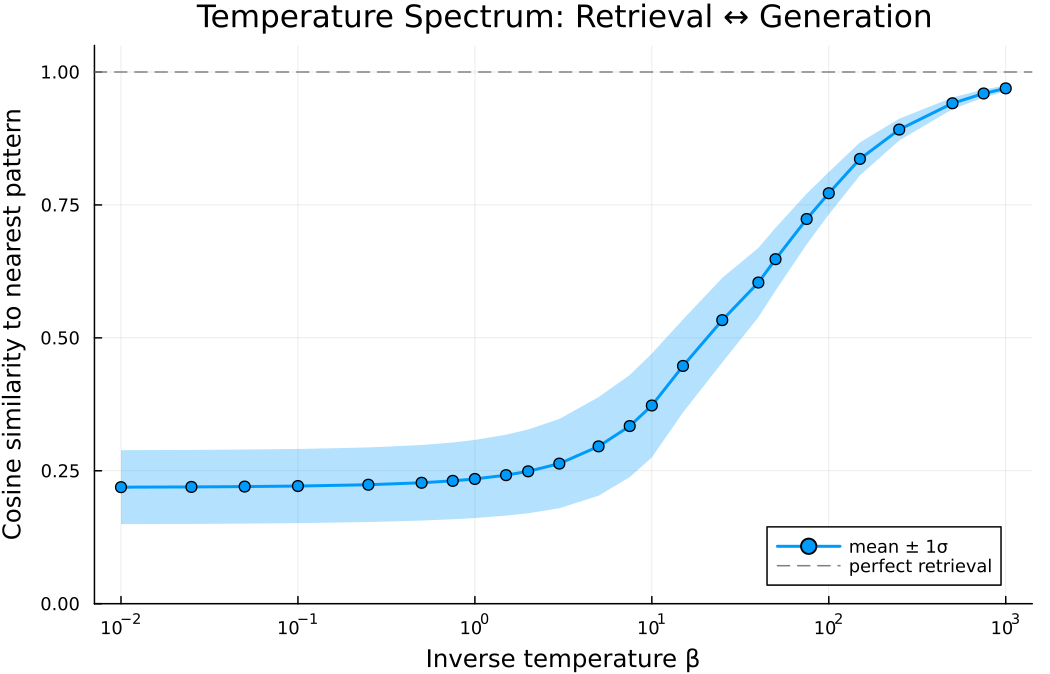

In [77]:
# Compute summary statistics for each β
β_sorted = sort(collect(keys(results)))
mean_sims = [mean(results[β]) for β in β_sorted]
std_sims  = [std(results[β]) for β in β_sorted]

# Plot: mean ± 1 std
p1 = plot(β_sorted, mean_sims;
    ribbon = std_sims,
    xscale = :log10,
    xlabel = "Inverse temperature β",
    ylabel = "Cosine similarity to nearest pattern",
    title  = "Temperature Spectrum: Retrieval ↔ Generation",
    label  = "mean ± 1σ",
    fillalpha = 0.3,
    linewidth = 2,
    marker = :circle,
    markersize = 4,
    legend = :bottomright,
    ylims  = (0, 1.05),
    xticks = [0.01, 0.1, 1, 10, 100, 1000],
    size   = (700, 450),
    dpi    = 150
)
hline!([1.0]; linestyle=:dash, color=:gray, label="perfect retrieval")
display(p1)

___
## Plot: Distribution of Cosine Similarities at Selected $\beta$
Violin/box plots at three representative temperatures to visualize the full distribution, not just the mean.

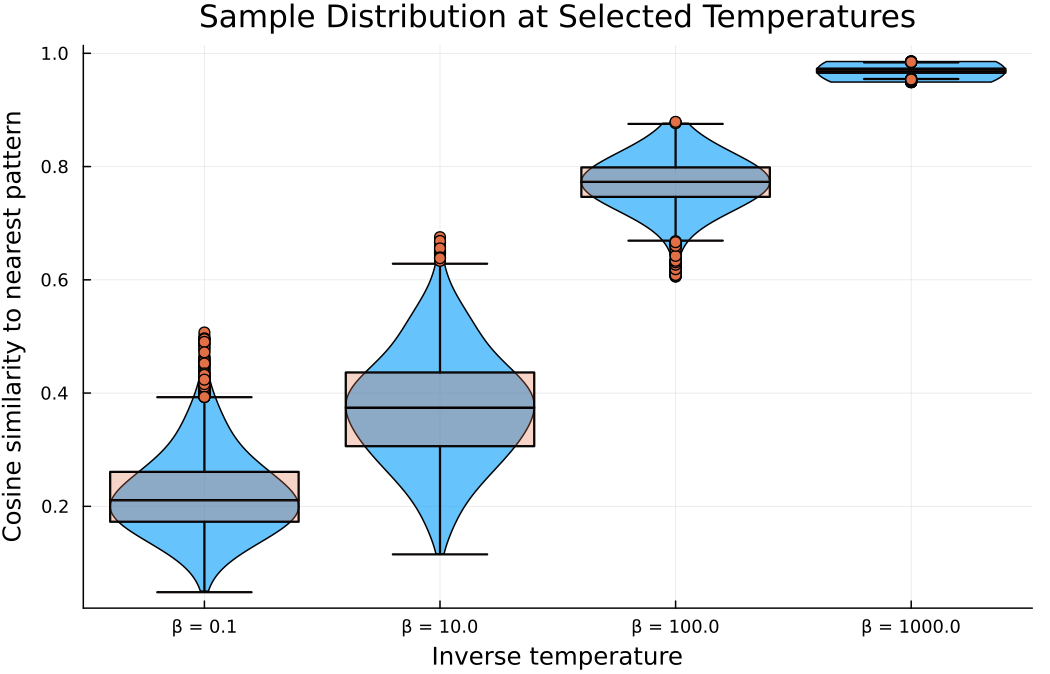

In [78]:
using CategoricalArrays

# Pick four representative β values: one per decade, small to large
β_subset = [0.1, 10.0, 100.0, 1000.0]

# Build a DataFrame with a CategoricalArray for ordered β labels
df_violin = DataFrame()
for β in β_subset
    sims = results[β]
    df_temp = DataFrame(
        :similarity => sims,
        :β => fill("β = $(β)", length(sims))
    )
    df_violin = vcat(df_violin, df_temp)
end

# Set explicit level ordering so StatsPlots respects small → large
df_violin.β = categorical(df_violin.β; levels=["β = $(β)" for β in β_subset], ordered=true)

p2 = @df df_violin violin(:β, :similarity;
    xlabel = "Inverse temperature",
    ylabel = "Cosine similarity to nearest pattern",
    title  = "Sample Distribution at Selected Temperatures",
    legend = false,
    fillalpha = 0.6,
    size   = (700, 450),
    dpi    = 150
)
@df df_violin boxplot!(:β, :similarity; fillalpha=0.3, linewidth=1.5)
display(p2)

___
## Plot: Sample Trajectories (Energy Over Time)
Show the energy trace $E(\boldsymbol{\xi}_t)$ for a few $\beta$ values to illustrate convergence behavior.

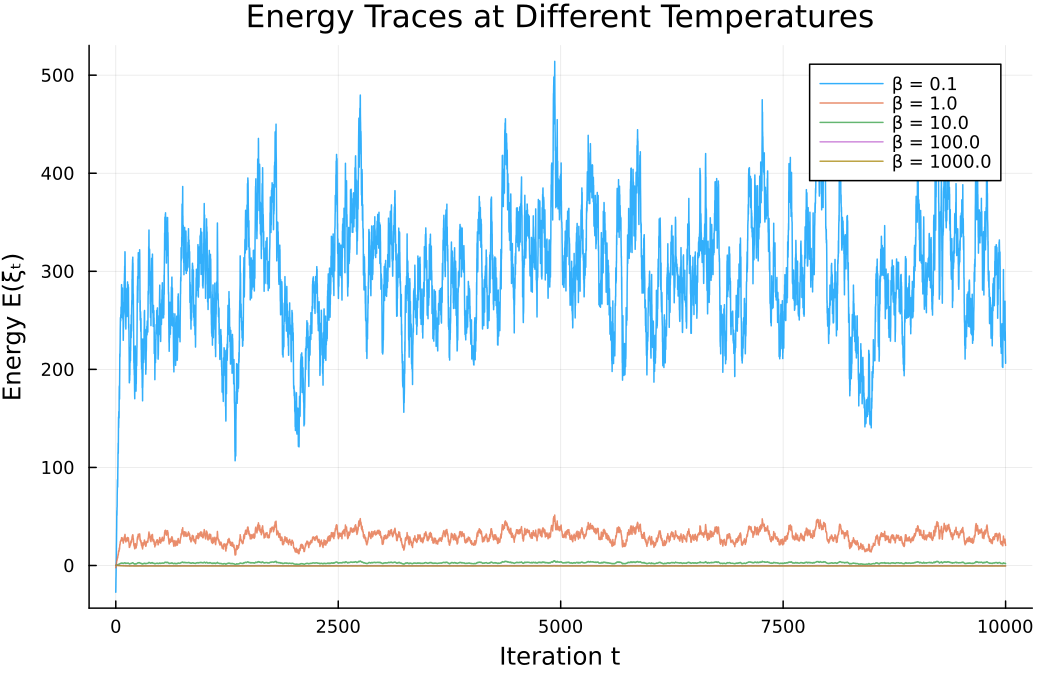

In [79]:
# Compute energy traces for selected β values
β_trace = [0.1, 1.0, 10.0, 100.0, 1000.0]
p3 = plot(;
    xlabel = "Iteration t",
    ylabel = "Energy E(ξₜ)",
    title  = "Energy Traces at Different Temperatures",
    legend = :topright,
    size   = (700, 450),
    dpi    = 150
)

for β in β_trace
    (t, Ξ) = sample(X, ξ₀, T; β=β, α=α, seed=12345)
    energies = [hopfield_energy(Ξ[i, :], X, β) for i in 1:(T+1)]
    plot!(p3, t, energies; label="β = $β", linewidth=1.0, alpha=0.8)
end
display(p3)

___
## Plot: Attention Entropy vs. $\beta$ (Order Parameter)
The Shannon entropy of the attention weights $\mathbf{p} = \operatorname{softmax}(\beta \mathbf{X}^\top \boldsymbol{\xi})$ serves as an order parameter for the retrieval transition. At small $\beta$ (high temperature) the weights are nearly uniform and $H \approx \log K$ (maximum disorder). As $\beta$ increases the distribution concentrates on one pattern and $H \to 0$ (perfect order). This mirrors the disordered-to-ordered phase transition in statistical mechanics.

β =   0.01: mean H = 2.7678, std = 0.0019
β =  0.025: mean H = 2.7606, std = 0.0047
β =   0.05: mean H = 2.7488, std = 0.0096
β =    0.1: mean H = 2.7251, std = 0.0197
β =   0.25: mean H = 2.655, std = 0.053
β =    0.5: mean H = 2.5402, std = 0.1154
β =   0.75: mean H = 2.4286, std = 0.1808
β =    1.0: mean H = 2.3204, std = 0.244
β =    1.5: mean H = 2.116, std = 0.3531
β =    2.0: mean H = 1.9274, std = 0.4372
β =    3.0: mean H = 1.5914, std = 0.5504
β =    5.0: mean H = 1.05, std = 0.6304
β =    7.5: mean H = 0.6144, std = 0.5495
β =   10.0: mean H = 0.3364, std = 0.4461
β =   15.0: mean H = 0.0788, std = 0.2038
β =   25.0: mean H = 0.0129, std = 0.077
β =   40.0: mean H = 0.0001, std = 0.0029
β =   50.0: mean H = 0.0, std = 0.0
β =   75.0: mean H = 0.0, std = 0.0
β =  100.0: mean H = 0.0, std = 0.0
β =  150.0: mean H = 0.0, std = 0.0
β =  250.0: mean H = 0.0, std = 0.0
β =  500.0: mean H = 0.0, std = 0.0
β =  750.0: mean H = 0.0, std = 0.0
β = 1000.0: mean H = 0.0, std = 0.0


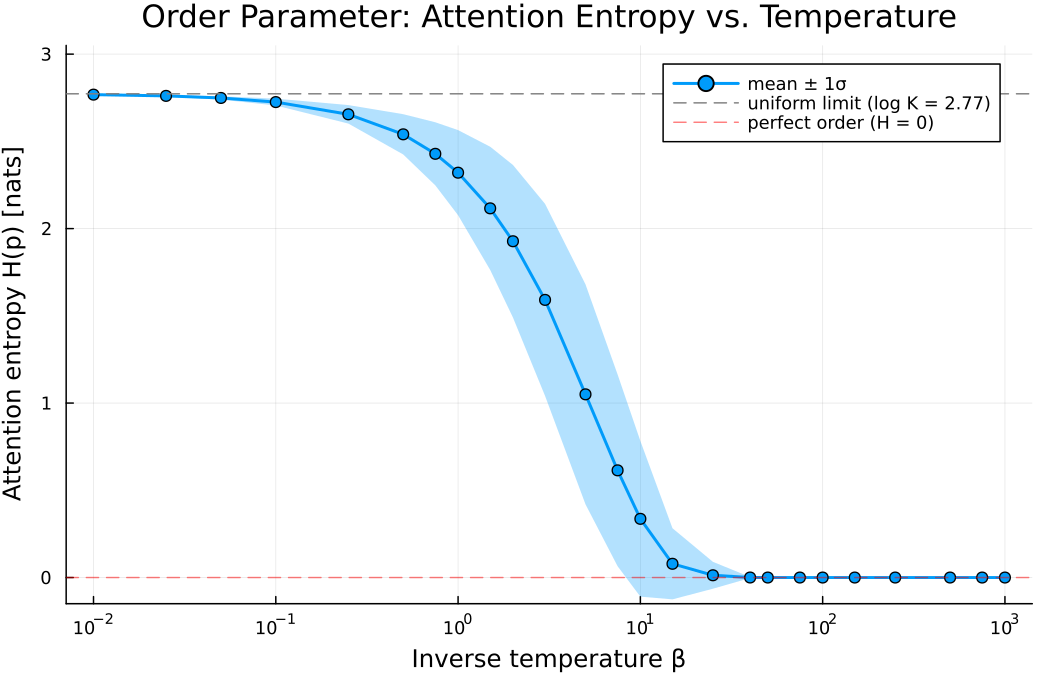

In [80]:
# Compute mean entropy for each β
entropy_results = Dict{Float64, Vector{Float64}}()
for β in β_values
    (t, Ξ) = sample(X, ξ₀, T; β=β, α=α, seed=12345)
    ents = Float64[]
    for i in (T_burnin + 2):(T + 1)
        ξ_t = Ξ[i, :]
        push!(ents, attention_entropy(ξ_t, X, β))
    end
    entropy_results[β] = ents
    println("β = $(lpad(β, 6)): mean H = $(round(mean(ents); digits=4)), ",
            "std = $(round(std(ents); digits=4))")
end

# Summary statistics
β_sorted = sort(collect(keys(entropy_results)))
mean_ent = [mean(entropy_results[β]) for β in β_sorted]
std_ent  = [std(entropy_results[β]) for β in β_sorted]

# Plot
p4 = plot(β_sorted, mean_ent;
    ribbon = std_ent,
    xscale = :log10,
    xlabel = "Inverse temperature β",
    ylabel = "Attention entropy H(p) [nats]",
    title  = "Order Parameter: Attention Entropy vs. Temperature",
    label  = "mean ± 1σ",
    fillalpha = 0.3,
    linewidth = 2,
    marker = :circle,
    markersize = 4,
    legend = :topright,
    ylims  = (-0.15, log(K) * 1.1),
    xticks = [0.01, 0.1, 1, 10, 100, 1000],
    size   = (700, 450),
    dpi    = 150
)
hline!([log(K)]; linestyle=:dash, color=:gray, label="uniform limit (log K = $(round(log(K); digits=2)))")
hline!([0.0]; linestyle=:dash, color=:red, alpha=0.5, label="perfect order (H = 0)")
display(p4)

___
## Paper Figure: Combined Cosine Similarity & Scaled Entropy
A single dual-axis panel showing both diagnostics on the same plot. The entropy is scaled by $\log K$ so both curves live on $[0,1]$. This replaces panels (a) and (b) in the paper figure, freeing one panel slot.

Saved: figs/Fig_experiment-1-phase-behavior.pdf


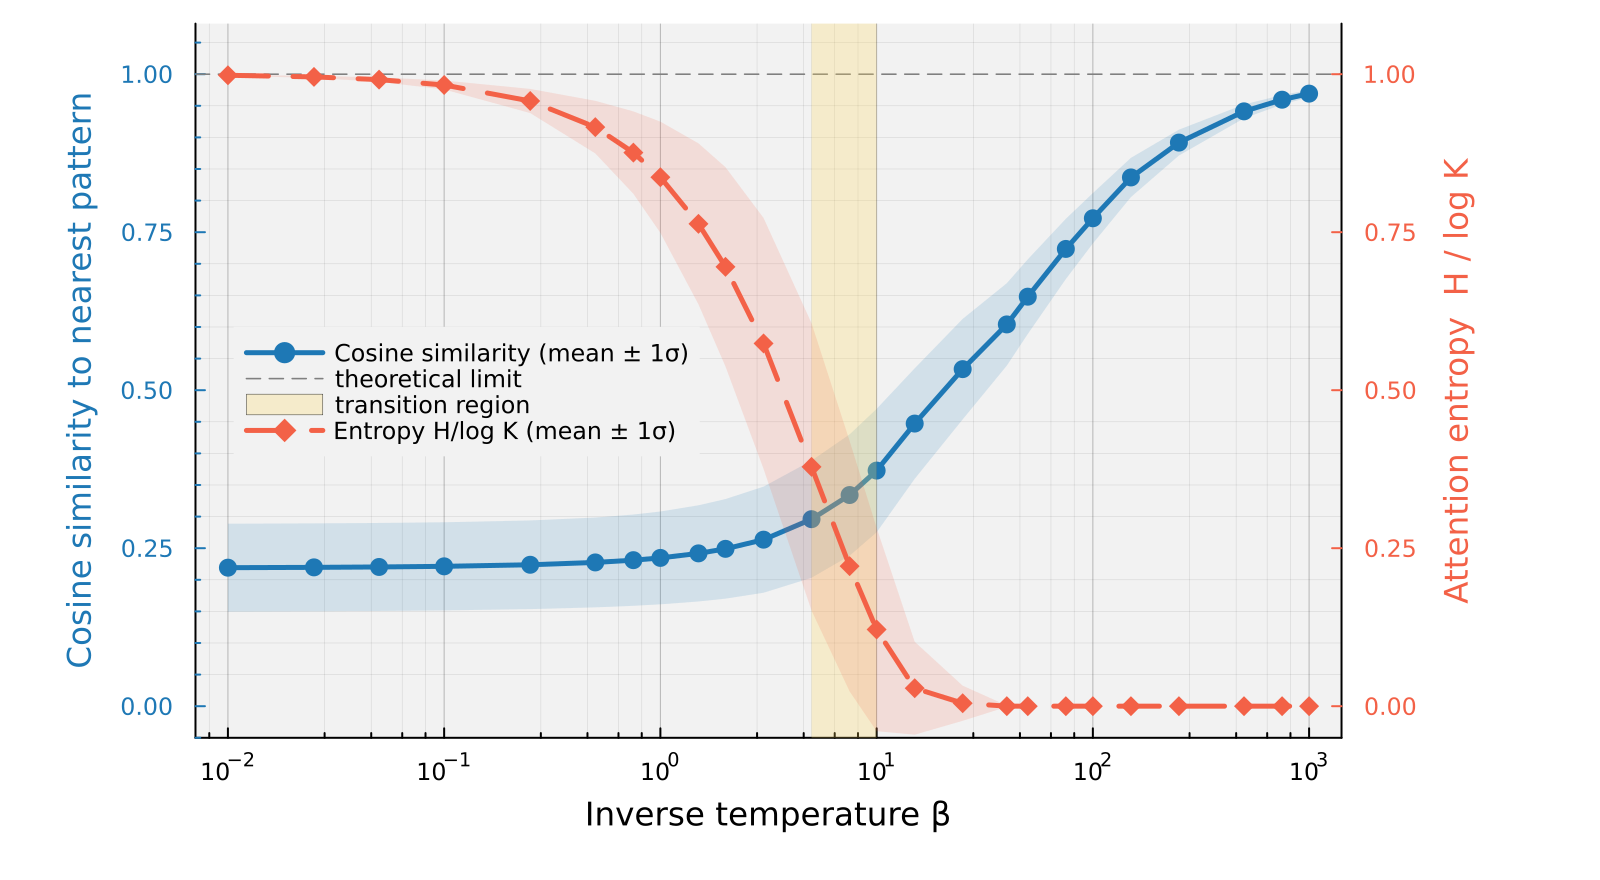

In [81]:
# Recompute sorted summary statistics (in case cells ran in different order)
β_sorted = sort(collect(keys(results)))
mean_sims = [mean(results[β]) for β in β_sorted]
std_sims  = [std(results[β]) for β in β_sorted]
mean_ent  = [mean(entropy_results[β]) for β in β_sorted]
std_ent   = [std(entropy_results[β]) for β in β_sorted]

# Scale entropy to [0,1] by dividing by log(K)
logK = log(K)
scaled_mean_ent = mean_ent ./ logK
scaled_std_ent  = std_ent ./ logK

# -- Color palette --
blue_color  = RGB(0.12, 0.47, 0.71)   # steel blue
coral_color = RGB(0.95, 0.38, 0.28)    # web 2.0 coral-red
gold_color  = RGB(1.0, 0.85, 0.35)     # warm gold for transition band

# -- Left axis: cosine similarity (blue) --
p_left = plot(β_sorted, mean_sims;
    ribbon    = std_sims,
    xscale    = :log10,
    xlabel    = "Inverse temperature β",
    ylabel    = "Cosine similarity to nearest pattern",
    label     = "Cosine similarity (mean ± 1σ)",
    color     = blue_color,
    fillalpha = 0.15,
    linewidth = 2.5,
    marker    = :circle,
    markersize = 5,
    markerstrokewidth = 0,
    legend    = :left,
    ylims     = (-0.05, 1.08),
    xticks    = [0.01, 0.1, 1, 10, 100, 1000],
    size      = (800, 440),
    dpi       = 200,
    grid      = true,
    gridalpha = 0.25,
    gridlinewidth = 0.5,
    gridcolor = :black,
    minorgrid = true,
    minorgridalpha = 0.12,
    minorgridlinewidth = 0.3,
    minorgridcolor = :black,
    minorticks = 5,
    bg        = "gray95",
    background_color_outside = "white",
    framestyle = :box,
    fg_legend  = :transparent,
    yguidefontcolor = blue_color,
    ytickfontcolor  = blue_color,
    yforeground_color_axis = blue_color,
    left_margin   = 10Plots.mm,
    bottom_margin = 8Plots.mm,
    right_margin  = 18Plots.mm,
)

# Theoretical limit line at y = 1
hline!([1.0]; linestyle = :dash, color = :gray, linewidth = 0.8, label = "theoretical limit")

# Transition region shading — warm gold band
vspan!([5.0, 10.0]; fillalpha = 0.25, color = gold_color, label = "transition region")

# -- Right axis: scaled entropy (coral) via twinx() --
p_right = twinx(p_left)
plot!(p_right, β_sorted, scaled_mean_ent;
    ribbon    = scaled_std_ent,
    xscale    = :log10,
    label     = "",
    ylabel    = "Attention entropy  H / log K",
    color     = coral_color,
    fillalpha = 0.15,
    linewidth = 2.5,
    marker    = :diamond,
    markersize = 5,
    markerstrokewidth = 0,
    linestyle = :dash,
    ylims     = (-0.05, 1.08),
    legend    = false,
    yguidefontcolor = coral_color,
    ytickfontcolor  = coral_color,
    yforeground_color_axis = coral_color,
)

# Add the entropy label to the LEFT plot's legend via a dummy invisible series
plot!(p_left, Float64[], Float64[];
    label = "Entropy H/log K (mean ± 1σ)",
    color = coral_color,
    linewidth = 2.5,
    linestyle = :dash,
    marker = :diamond,
    markersize = 5,
    markerstrokewidth = 0,
)

# Save to PDF in figs/ directory
_PATH_TO_FIGS = joinpath(_ROOT, "figs")
mkpath(_PATH_TO_FIGS)
savefig(p_left, joinpath(_PATH_TO_FIGS, "Fig_experiment-1-phase-behavior.pdf"))
println("Saved: figs/Fig_experiment-1-phase-behavior.pdf")

display(p_left)

___
## Summary
We swept the inverse temperature across several orders of magnitude and characterized three operating regimes of the stochastic attention sampler.

> __Key Takeaways:__
>
> * **Three regimes:** The sampler transitions from diffuse noise (small beta) through structured generation (intermediate beta) to near-perfect pattern retrieval (large beta), as measured by cosine similarity to the nearest stored pattern
> * **Attention entropy as order parameter:** The Shannon entropy of the softmax attention weights decreases monotonically from log K (uniform) to zero (concentrated), mirroring the disordered-to-ordered phase transition in statistical mechanics
> * **Smooth interpolation:** The combined cosine similarity and scaled entropy plot confirms that inverse temperature provides a single control knob for trading off novelty against fidelity

___